In [1]:
import pandas as pd 
import numpy as np


In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [6]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

# Stpes 

# 1. loading the dataset
# 2.  data -> tensor 
# 3. tensorDataset and datasetloader
# 4.define the model 
# 5. train the model 

In [8]:
from  sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
X_train.shape

(7654, 4)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# dataset and loaderdataset

In [21]:
import torch 
import torch.nn as nn 

In [24]:
X_train_tensor = torch.tensor(X_train_sc, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_sc, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


In [26]:
from torch.utils.data import TensorDataset, DataLoader 

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor )

In [28]:
train_dataLoader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataLoader = DataLoader(test_dataset, batch_size=32)

# main model creating and here we biuld our ANN model 

In [47]:
import torch
import torch.nn as nn
import torch.optim as optim


class ANN(nn.Module):

    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            nn.Linear(6, 6),
            nn.ReLU(),

            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)


model = ANN()

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters())

In [53]:
train_loss = []
validate_loss = []
running_val_loss=0.0

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0


    for xb, yb in train_dataLoader:

        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()

    epoch_train_loss = running_loss / len(train_dataLoader)
    train_loss.append(epoch_train_loss)
    
    with torch.no_grad():
        for xb, yb in test_dataLoader:
            output = model(xb)
            loss = criterion(output, yb)
            running_val_loss+=loss

    running_val_loss = running_val_loss/len(test_dataLoader)
    validate_loss.append(running_val_loss)

    print(f"{epoch}/{epochs} running_loss is {running_loss} and running_val_loss is {running_val_loss}")
        
        
            
            

    
        
        

0/100 running_loss is 5008.809464454651 and running_val_loss is 18.884065628051758
1/100 running_loss is 4968.276204109192 and running_val_loss is 19.432201385498047
2/100 running_loss is 4996.700716018677 and running_val_loss is 19.857120513916016
3/100 running_loss is 4969.760829925537 and running_val_loss is 19.431013107299805
4/100 running_loss is 4979.058897972107 and running_val_loss is 19.927417755126953
5/100 running_loss is 4982.0997223854065 and running_val_loss is 19.46648406982422
6/100 running_loss is 4956.288249969482 and running_val_loss is 19.31245994567871
7/100 running_loss is 4994.299262046814 and running_val_loss is 19.24228858947754
8/100 running_loss is 4967.416835784912 and running_val_loss is 19.18184471130371
9/100 running_loss is 4961.90970993042 and running_val_loss is 19.550872802734375
10/100 running_loss is 4984.091302871704 and running_val_loss is 19.269039154052734
11/100 running_loss is 4980.177489757538 and running_val_loss is 19.368518829345703
12/100

In [54]:
import matplotlib.pyplot as plt

In [57]:
loss_df =pd.DataFrame({
    "train_loss":train_loss,
    "val_loss":validate_loss
    
})

Text(0, 0.5, 'loss')

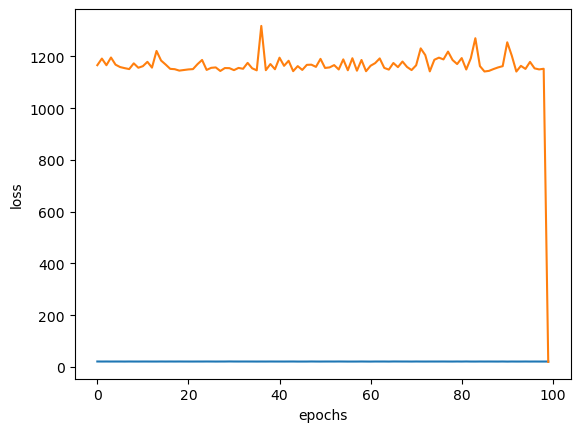

In [61]:
plt.plot(
    loss_df["train_loss"], label="train_loss"
)
plt.plot(
    loss_df["val_loss"], label="val_loss"
)

plt.xlabel("epochs")
plt.ylabel("loss")